# Premier League Transfer Spending & Success

This project examines the relationship between transfer spending and the success of English Premier League clubs from the 2019–20 through 2024–25 seasons.

The analysis combines Premier League match results with transfer expenditure data to see whether clubs that spend more on transfers tend to earn more league points.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import io

## Data Collection

I collected Premier League match and transfer data from publicly available web sources. Football-Data.co.uk provides historical Premier League match results, while Transfermarkt provides club transfer expenditure and income by season. The data will be collected and combined using Python and pandas.

In [2]:
url = "https://www.football-data.co.uk/mmz4281/2425/E0.csv"

results = pd.read_csv(url)

results.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,16/08/2024,20:00,Man United,Fulham,1,0,H,0,0,...,1.86,2.07,1.83,2.11,1.88,2.11,1.82,2.05,1.90,2.08
1,E0,17/08/2024,12:30,Ipswich,Liverpool,0,2,A,0,0,...,2.05,1.88,2.04,1.90,2.20,2.00,1.99,1.88,2.04,1.93
2,E0,17/08/2024,15:00,Arsenal,Wolves,2,0,H,1,0,...,2.02,1.91,2.00,1.90,2.05,1.93,1.99,1.87,2.02,1.96
3,E0,17/08/2024,15:00,Everton,Brighton,0,3,A,0,1,...,1.87,2.06,1.86,2.07,1.92,2.10,1.83,2.04,1.88,2.11
4,E0,17/08/2024,15:00,Newcastle,Southampton,1,0,H,1,0,...,1.87,2.06,1.88,2.06,1.89,2.10,1.82,2.05,1.89,2.10


In [6]:
results.shape

(380, 120)

In [7]:
results.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA',
       'AvgCAHH', 'AvgCAHA', 'BFECAHH', 'BFECAHA'],
      dtype='str', length=120)

In [8]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Columns: 120 entries, Div to BFECAHA
dtypes: float64(96), int64(16), str(8)
memory usage: 356.4 KB


In [9]:
results.isna().sum()

Div         0
Date        0
Time        0
HomeTeam    0
AwayTeam    0
           ..
MaxCAHA     0
AvgCAHH     0
AvgCAHA     0
BFECAHH     0
BFECAHA     0
Length: 120, dtype: int64

In [10]:
results.describe()

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,...,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,1.513158,1.421053,0.752632,0.610526,13.752632,12.165789,4.834211,4.265789,10.789474,11.276316,...,1.946421,1.964842,1.954632,1.971605,1.987842,2.003026,1.925105,1.939237,1.983079,2.006079
std,1.277917,1.189922,0.875867,0.828831,5.588045,5.409987,2.488260,2.341636,3.639840,3.513257,...,0.086484,0.085585,0.084978,0.086511,0.087387,0.087857,0.080514,0.080919,0.088226,0.089331
min,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000,...,1.680000,1.730000,1.710000,1.770000,1.830000,1.800000,1.730000,1.750000,1.750000,1.810000
25%,1.000000,1.000000,0.000000,0.000000,10.000000,9.000000,3.000000,3.000000,8.000000,9.000000,...,1.880000,1.907500,1.880000,1.900000,1.910000,1.940000,1.857500,1.870000,1.910000,1.930000
50%,1.000000,1.000000,1.000000,0.000000,13.000000,11.500000,5.000000,4.000000,11.000000,11.000000,...,1.950000,1.970000,1.950000,1.970000,1.990000,2.000000,1.920000,1.940000,1.980000,2.010000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,15.000000,6.000000,6.000000,13.000000,14.000000,...,2.020000,2.040000,2.020000,2.040000,2.050000,2.072500,1.990000,2.010000,2.052500,2.070000
max,7.000000,6.000000,4.000000,5.000000,36.000000,37.000000,16.000000,13.000000,21.000000,21.000000,...,2.100000,2.150000,2.170000,2.260000,2.340000,2.310000,2.130000,2.140000,2.210000,2.300000


In [11]:
match_data = results[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']]

match_data.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,16/08/2024,Man United,Fulham,1,0,H
1,17/08/2024,Ipswich,Liverpool,0,2,A
2,17/08/2024,Arsenal,Wolves,2,0,H
3,17/08/2024,Everton,Brighton,0,3,A
4,17/08/2024,Newcastle,Southampton,1,0,H


In [12]:
match_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      380 non-null    str  
 1   HomeTeam  380 non-null    str  
 2   AwayTeam  380 non-null    str  
 3   FTHG      380 non-null    int64
 4   FTAG      380 non-null    int64
 5   FTR       380 non-null    str  
dtypes: int64(2), str(4)
memory usage: 17.9 KB


In [13]:
match_data.isna().sum()

Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
dtype: int64

## 1. Collecting the Data

### Premier League Match Data

I collected Premier League match results for six seasons from Football-Data.co.uk. Each row in the original dataset represents one match. I selected the 2019–20 through 2024–25 seasons so that the analysis covers multiple seasons instead of relying on just one year.


In [39]:
seasons = {
    '2019-20': '1920',
    '2020-21': '2021',
    '2021-22': '2122',
    '2022-23': '2223',
    '2023-24': '2324',
    '2024-25': '2425'
}

all_results = []

for season, season_code in seasons.items():
    url = f"https://www.football-data.co.uk/mmz4281/{season_code}/E0.csv"
    
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    data = pd.read_csv(io.StringIO(response.text))
    
    data = data[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']]
    data['Season'] = season
    
    all_results.append(data)

all_results = pd.concat(all_results, ignore_index=True)

all_results.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season
0,09/08/2019,Liverpool,Norwich,4,1,H,2019-20
1,10/08/2019,West Ham,Man City,0,5,A,2019-20
2,10/08/2019,Bournemouth,Sheffield United,1,1,D,2019-20
3,10/08/2019,Burnley,Southampton,3,0,H,2019-20
4,10/08/2019,Crystal Palace,Everton,0,0,D,2019-20


## Checking the Collected Match Data

I checked the size of the dataset, the number of matches in each season, and whether there were any missing values in the variables I used. This helped confirm that the data was collected correctly before moving on to the analysis.

In [40]:
print("Total matches:", len(all_results))
print("Matches by season:")
print(all_results['Season'].value_counts().sort_index())
print("\nMissing values:")
print(all_results.isna().sum())

Total matches: 2280
Matches by season:
Season
2019-20    380
2020-21    380
2021-22    380
2022-23    380
2023-24    380
2024-25    380
Name: count, dtype: int64

Missing values:
Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
Season      0
dtype: int64


## Creating Team-Level Performance Data

The original match data has one row for each game, but my research question focuses on the performance of each club. I used the match results to create one observation for each club in each season.

For each club, I calculated league points, goals scored, goals conceded, and goal difference. League points were calculated using the standard scoring system of 3 points for a win and 1 point for a draw.

In [ ]:
team_stats_all = []

for season in seasons:
    season_data = all_results[all_results['Season'] == season]
    
    teams = pd.concat([
        season_data['HomeTeam'],
        season_data['AwayTeam']
    ]).unique()
    
    for team in teams:
        home_games = season_data[season_data['HomeTeam'] == team]
        away_games = season_data[season_data['AwayTeam'] == team]
        # Calculate points separately for home and away games
        home_points = (
            (home_games['FTR'] == 'H').sum() * 3
            + (home_games['FTR'] == 'D').sum()
        )
        
        away_points = (
            (away_games['FTR'] == 'A').sum() * 3
            + (away_games['FTR'] == 'D').sum()
        )
        # Calculate goals scored and conceded
        goals_scored = (
            home_games['FTHG'].sum()
            + away_games['FTAG'].sum()
        )
        
        goals_conceded = (
            home_games['FTAG'].sum()
            + away_games['FTHG'].sum()
        )
        
        team_stats_all.append({
            'Season': season,
            'Club': team,
            'League_Points': home_points + away_points,
            'Goals_Scored': goals_scored,
            'Goals_Conceded': goals_conceded
        })

team_stats_all = pd.DataFrame(team_stats_all)

team_stats_all['Goal_Difference'] = (
    team_stats_all['Goals_Scored']
    - team_stats_all['Goals_Conceded']
)

## Calculating Final League Position

I sorted the clubs within each season by league points and goal difference. I then used these values to assign each club a final position from 1st to 20th for each season.

In [42]:
team_stats_all = team_stats_all.sort_values(
    ['Season', 'League_Points', 'Goal_Difference'],
    ascending=[True, False, False]
)

team_stats_all['Final_Position'] = (
    team_stats_all.groupby('Season').cumcount() + 1
)

team_stats_all.head(20)

,Season,Club,League_Points,Goals_Scored,Goals_Conceded,Goal_Difference,Final_Position
0,2019-20,Liverpool,99,85,33,52,1
16,2019-20,Man City,81,102,35,67,2
9,2019-20,Man United,66,66,36,30,3
18,2019-20,Chelsea,66,69,54,15,4
7,2019-20,Leicester,62,67,41,26,5
6,2019-20,Tottenham,59,61,47,14,6
19,2019-20,Wolves,59,51,40,11,7
10,2019-20,Arsenal,56,56,48,8,8
17,2019-20,Sheffield United,54,39,39,0,9
3,2019-20,Burnley,54,43,50,-7,10


## Collecting Transfer Expenditure Data

I used web scraping to collect Premier League transfer expenditure data from Transfermarkt for each of the six seasons. The function collects each club's reported transfer expenditure and stores it along with the season and club name. I then converted the expenditure values from text into numbers so they could be used in the analysis.

In [ ]:
def scrape_transfer_expenditure(season, season_id):
    url = (
        f"https://www.transfermarkt.com/premier-league/"
        f"einnahmenausgaben/wettbewerb/GB1/ids/a/sa//"
        f"saison_id/{season_id}/saison_id_bis/{season_id}/"
        f"nat/0/pos//w_s/intern/0/plus/1"
    )
    
    response = requests.get(
        url,
        headers={'User-Agent': 'Mozilla/5.0'},
        timeout=30
    )
    
    response.raise_for_status()
    
    soup = BeautifulSoup(response.text, 'html.parser')
    tables = soup.find_all('table')
    
    transfer_rows = tables[1].find_all('tr')
    
    transfer_data = []
    
    for row in transfer_rows[1:]:
        cells = row.find_all('td')
        
        if len(cells) >= 8:
            club = cells[2].get_text(" ", strip=True)
            expenditure = cells[3].get_text(" ", strip=True)
            
            transfer_data.append({
                'Season': season,
                'Club': club,
                'Transfer_Expenditure': expenditure
            })
    
    transfer_data = pd.DataFrame(transfer_data)
    # Remove currency/unit symbols and convert values to numbers
    transfer_data['Transfer_Expenditure'] = (
        transfer_data['Transfer_Expenditure']
        .str.replace('€', '', regex=False)
        .str.replace('m', '', regex=False)
        .astype(float)
    )
    
    return transfer_data

## Collecting Transfer Data for All Seasons

I repeated the scraping process for all six seasons and combined the results into one dataset. I also checked the number of club-season records collected for each season to make sure the data was complete.

In [45]:
transfer_seasons = {
    '2019-20': 2019,
    '2020-21': 2020,
    '2021-22': 2021,
    '2022-23': 2022,
    '2023-24': 2023,
    '2024-25': 2024
}

all_transfers = []

for season, season_id in transfer_seasons.items():
    data = scrape_transfer_expenditure(season, season_id)
    all_transfers.append(data)

all_transfers = pd.concat(all_transfers, ignore_index=True)

print("Total club-season records:", len(all_transfers))
print("\nRecords by season:")
print(all_transfers['Season'].value_counts().sort_index())

Total club-season records: 120

Records by season:
Season
2019-20    20
2020-21    20
2021-22    20
2022-23    20
2023-24    20
2024-25    20
Name: count, dtype: int64


## Standardizing Club Names

The two datasets did not always use the same names for the same clubs. I standardized the club names so the match and transfer data could be correctly combined.

In [46]:
club_name_map = {
    'Liverpool FC': 'Liverpool',
    'Arsenal FC': 'Arsenal',
    'Manchester City': 'Man City',
    'Chelsea FC': 'Chelsea',
    'Newcastle United': 'Newcastle',
    'Aston Villa': 'Aston Villa',
    'Nottingham Forest': "Nott'm Forest",
    'Brighton & Hove Albion': 'Brighton',
    'AFC Bournemouth': 'Bournemouth',
    'Brentford FC': 'Brentford',
    'Fulham FC': 'Fulham',
    'Crystal Palace': 'Crystal Palace',
    'Everton FC': 'Everton',
    'West Ham United': 'West Ham',
    'Manchester United': 'Man United',
    'Wolverhampton Wanderers': 'Wolves',
    'Tottenham Hotspur': 'Tottenham',
    'Leicester City': 'Leicester',
    'Ipswich Town': 'Ipswich',
    'Southampton FC': 'Southampton',
    'Sheffield United': 'Sheffield United',
    'Burnley FC': 'Burnley',
    'Watford FC': 'Watford',
    'Norwich City': 'Norwich'
}

all_transfers['Club'] = all_transfers['Club'].replace(club_name_map)

all_transfers.head(20)

,Season,Club,Transfer_Expenditure
0,2019-20,Man United,236.80
1,2019-20,Man City,169.82
2,2019-20,Arsenal,160.80
3,2019-20,Aston Villa,159.50
4,2019-20,Tottenham,150.50
5,2019-20,Everton,121.00
6,2019-20,West Ham,119.80
7,2019-20,Wolves,116.70
8,2019-20,Leicester,104.30
9,2019-20,Sheffield United,72.50


## Checking Club Name Matches

I compared the club names from both datasets to make sure the names were standardized correctly before merging the data.

In [47]:
print("Football-Data club names:")
print(sorted(team_stats_all['Club'].unique()))

print("\nTransfermarkt club names:")
print(sorted(all_transfers['Club'].unique()))

Football-Data club names:
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Newcastle', 'Norwich', "Nott'm Forest", 'Sheffield United', 'Southampton', 'Tottenham', 'Watford', 'West Brom', 'West Ham', 'Wolves']

Transfermarkt club names:
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leeds United', 'Leicester', 'Liverpool', 'Luton Town', 'Man City', 'Man United', 'Newcastle', 'Norwich', "Nott'm Forest", 'Sheffield United', 'Southampton', 'Tottenham', 'Watford', 'West Bromwich Albion', 'West Ham', 'Wolves']


In [48]:
all_transfers['Club'] = all_transfers['Club'].replace({
    'Leeds United': 'Leeds',
    'Luton Town': 'Luton',
    'West Bromwich Albion': 'West Brom'
})

## Combining the Performance and Transfer Data

I merged the team performance data with the transfer expenditure data using the club and season. This created one dataset where each row represents a club in a specific season, with both its performance and transfer spending information.

In [49]:
analysis_data_all = pd.merge(
    team_stats_all,
    all_transfers,
    on=['Season', 'Club'],
    how='inner'
)

In [50]:
print("Total club-season records:", len(analysis_data_all))

print("\nMissing values:")
print(analysis_data_all.isna().sum())

print("\nRecords by season:")
print(analysis_data_all['Season'].value_counts().sort_index())

Total club-season records: 120

Missing values:
Season                  0
Club                    0
League_Points           0
Goals_Scored            0
Goals_Conceded          0
Goal_Difference         0
Final_Position          0
Transfer_Expenditure    0
dtype: int64

Records by season:
Season
2019-20    20
2020-21    20
2021-22    20
2022-23    20
2023-24    20
2024-25    20
Name: count, dtype: int64


## Analyzing the Relationships

I calculated the correlations between transfer expenditure, league points, and final league position. This helps show how strongly transfer spending is related to team success across the six seasons.

In [51]:
correlation = analysis_data_all[
    ['Transfer_Expenditure', 'League_Points', 'Final_Position']
].corr()

correlation

,Transfer_Expenditure,League_Points,Final_Position
Transfer_Expenditure,1.000000,0.264929,-0.298815
League_Points,0.264929,1.000000,-0.963797
Final_Position,-0.298815,-0.963797,1.000000


In [ ]:
points_correlation = analysis_data_all[
    'Transfer_Expenditure'
].corr(
    analysis_data_all['League_Points']
)

print("Correlation between transfer expenditure and league points:",
      round(points_correlation, 3))

Correlation between transfer expenditure and league points: 0.265


In [53]:
r_squared = 0.265 ** 2

print("R-squared:", round(r_squared, 3))
print("Percent of variation in league points associated with transfer expenditure:",
      round(r_squared * 100, 1), "%")

R-squared: 0.07
Percent of variation in league points associated with transfer expenditure: 7.0 %


## Visualization 1: Transfer Spending and League Points

This scatterplot compares transfer expenditure with league points for 120 club-season observations from 2019–20 through 2024–25. The trend line shows a slight positive relationship between spending and points, which is consistent with the correlation of 0.265. However, the observations are widely spread around the trend line, suggesting that transfer expenditure alone does not strongly explain league success.

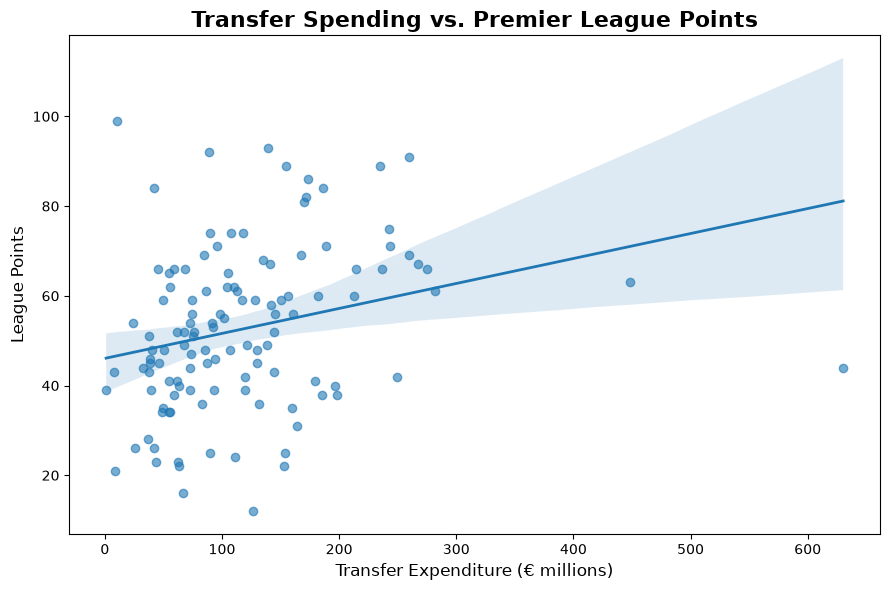

In [70]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=analysis_data_all,
    x='Transfer_Expenditure',
    y='League_Points',
    scatter_kws={'alpha': 0.6},
    line_kws={'linewidth': 2}
)

plt.title(
    'Transfer Spending vs. Premier League Points',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Transfer Expenditure (€ millions)', fontsize=12)
plt.ylabel('League Points', fontsize=12)

plt.tight_layout()
plt.savefig('transfer-spending-points.png')
plt.show()

In [55]:
analysis_data_all['Spending_Quartile'] = pd.qcut(
    analysis_data_all['Transfer_Expenditure'],
    q=4,
    labels=[
        'Lowest Spending',
        'Lower-Middle Spending',
        'Upper-Middle Spending',
        'Highest Spending'
    ]
)

## Visualization 2: Spending Groups Across Seasons

This heatmap compares the average league points earned by clubs in different transfer spending groups across the six seasons. The spending groups are based on quartiles, with clubs divided into four groups from lowest spending to highest spending. This helps show whether the relationship between spending and league points is consistent across seasons.

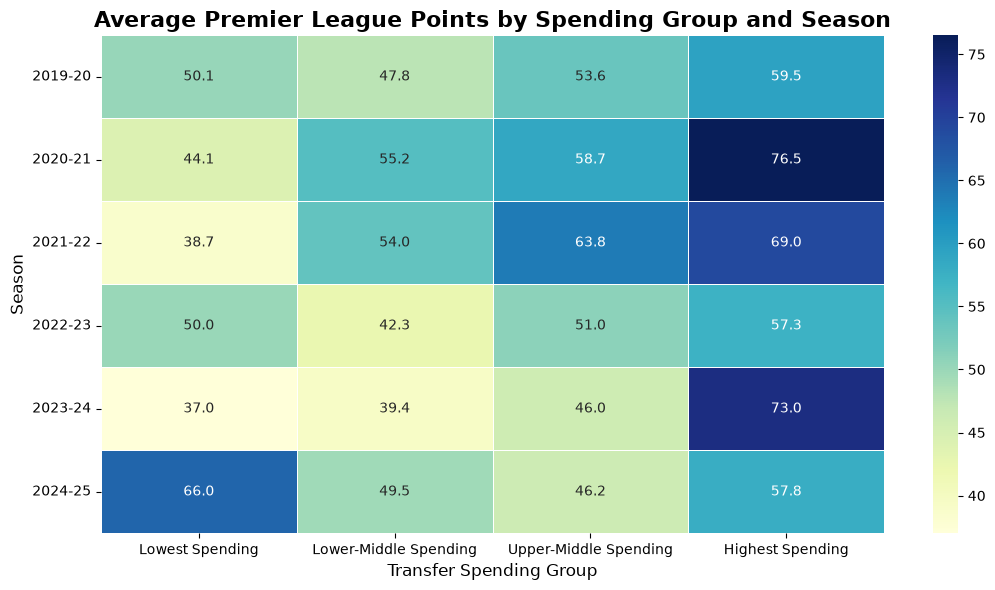

In [69]:
season_order = [
    '2019-20',
    '2020-21',
    '2021-22',
    '2022-23',
    '2023-24',
    '2024-25'
]

heatmap_data = heatmap_data.reindex(season_order)

plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title(
    'Average Premier League Points by Spending Group and Season',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Transfer Spending Group', fontsize=12)
plt.ylabel('Season', fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('spending-heatmap.png')
plt.show()

# Storytelling and Narrative

The results show that there is a small positive relationship between transfer spending and league success. The correlation between transfer spending and league points was 0.265. In simple terms, teams that spent more money on transfers generally earned more points, but the relationship was not very strong. Transfer spending only explained about 7% of the differences in league points between teams.

The scatterplot shows this because the teams are spread out instead of being close to the trend line. The heatmap also shows that the relationship can change from season to season. This tells us that spending money is not the only thing that matters when it comes to having a successful team. Things like coaching, player development, injuries, and the quality of players already on the team could also have an impact.

Overall, our results suggest that spending more on transfers can be related to better results, but it does not guarantee success. A team can spend a lot of money and still have a poor season. Because of this, we cannot say that transfer spending directly causes a team to be more successful.


# Limitations, Ethics, and Reflection

There are a few limitations to consider when looking at these results. First, transfer spending is only one part of how a club builds its team. This dataset does not include things like player wages, coaching, injuries, or the quality of a club's existing players. These factors could also have a major effect on how successful a team is.

Another limitation is that the transfer spending data includes transfers made during the season. Because of this, the spending may not always happen before the team earns its points, which makes it harder to use spending as a true predictor of success. Also, the data covers six seasons, so different teams and different circumstances can affect the results from one season to another.

There are also some limitations with the data sources. Transfermarkt is a secondary source, meaning the transfer information was collected and reported by another organization rather than directly from the clubs. Transfer fees may also be reported differently depending on the source.

Finally, the results only show a relationship between spending and success. They do not prove that spending more money causes a team to perform better. A club could spend a lot and still perform poorly, while another club could spend less and have a successful season. Because of these limitations, the results should be viewed as one way of looking at the relationship between transfer spending and Premier League success rather than a complete explanation of why teams succeed.
